In [3]:
import pandas as pd 
import graph_tool.all as gt
import numpy as np 
gene_expression_by_tissue = pd.read_csv("./data/expression_by_tissue.gct", sep="\t", skiprows=2, header = 0)
expressed_genes = gene_expression_by_tissue[gene_expression_by_tissue["Bladder"] > 1]["Name"]
expressed_genes = list(gene.split(".")[0] for gene in expressed_genes)
print(expressed_genes[:10])


['ENSG00000310526', 'ENSG00000308579', 'ENSG00000269981', 'ENSG00000310527', 'ENSG00000225880', 'ENSG00000225972', 'ENSG00000225630', 'ENSG00000237973', 'ENSG00000229344', 'ENSG00000240409']


In [ ]:
network = gt.load_graph("./data/test_network.gt")
node_names = []
for v in network.vertices():
    node_names.append(network.vp.name[v])
gene_expression_by_tissue["Name"] = gene_expression_by_tissue["Name"].apply(lambda x: x.split(".")[0])
in_network_genes = gene_expression_by_tissue[gene_expression_by_tissue["Name"].isin(node_names)]
bladder_specific = in_network_genes[in_network_genes["Bladder"] > 1]["Name"]
bladder_specific = list(bladder_specific)





61    ENSG00000188976
69    ENSG00000187608
73    ENSG00000188157
91    ENSG00000186891
92    ENSG00000186827
Name: Name, dtype: str

6301


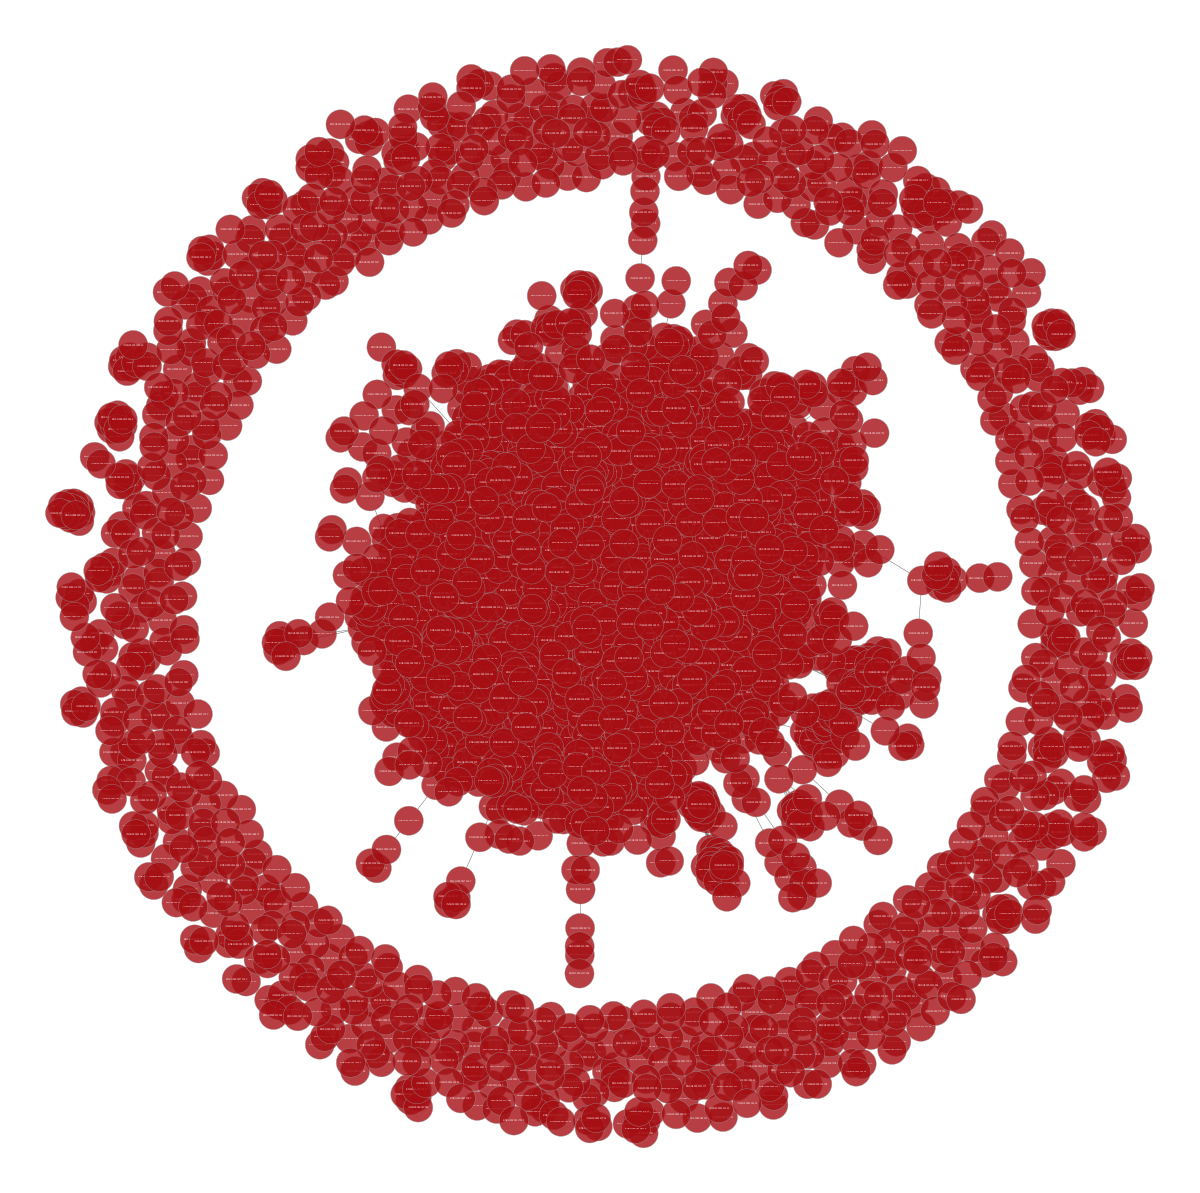

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x16bc8fa80, at 0x30c6d4050>

In [43]:
import diseasemodulediscovery.bin.util as utils 
network = utils.load_graph('data/test_network.gt')
names = utils.name2index(network)
gene_expression_by_tissue = pd.read_csv("./data/expression_by_tissue.gct", sep="\t", skiprows=2, header = 0)
gene_expression_by_tissue["Name"] = gene_expression_by_tissue["Name"].apply(lambda x: x.split(".")[0])
gene_expression_by_tissue = gene_expression_by_tissue[gene_expression_by_tissue["Name"].isin(names.keys())]
gene_expression_by_tissue["node_id"] = gene_expression_by_tissue["Name"].map(names)
bladder_specific = gene_expression_by_tissue[gene_expression_by_tissue["Bladder"] > 1]
filter = network.new_vertex_property("bool")
filter.a[bladder_specific["node_id"]] = True
network.set_vertex_filter(filter)
network.purge_vertices()
network.clear_filters()
print(network.num_vertices())
gt.graph_draw(network, vertex_text=network.vp.name)


In [4]:
from pybiomart import Dataset

CHUNK_SIZE = 50

def chunks(values, chunk_size=CHUNK_SIZE):
    for start in range(0, len(values), chunk_size):
        yield values[start:start + chunk_size]

dataset_name = "hsapiens_gene_ensembl"
host = "www.ensembl.org"
dataset = Dataset(name=dataset_name, host=host)

results = []
for gene_chunk in chunks(expressed_genes):
    chunk_df = dataset.query(
        attributes=["ensembl_gene_id", "external_gene_name"],
        filters={"gene_id": gene_chunk},
    )
    if not chunk_df.empty:
        results.append(chunk_df)

if not results:
    raise ValueError("No genes found in the specified id space. Please check the id space and gene names.")

df = pd.concat(results, ignore_index=True).drop_duplicates()
print(df.head())


KeyboardInterrupt: 

In [5]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)
gene_expression_by_tissue["Name"] = gene_expression_by_tissue["Name"].apply(lambda x: x.split(".")[0])
tissue_specific_expression = gene_expression_by_tissue[["Name", "Bladder"]]
print(tissue_specific_expression.shape)
df = gp.convert(organism="hsapiens", query=tissue_specific_expression["Name"].tolist(), target_namespace="HGNC")
print(df.shape)
df = df.merge(tissue_specific_expression, left_on="incoming", right_on="Name")
df = df[["Name", "converted", "Bladder"]]
not_found = df.loc[df["converted"].astype(str) == "None", "Name"].nunique()
print(not_found)
collapsed = (
    df[(df["converted"].astype(str) != "None")]
    .assign(name=lambda x : x["converted"].astype(str))
    .drop(columns=["Name"])
    .groupby("converted", as_index=False)
    .agg({
        "Bladder": "sum",
    })
)
print(collapsed.shape)
collapsed.head()



(74628, 2)
(74632, 8)
35211
(39306, 2)


,converted,Bladder
0,A1BG,1.658670
1,A1BG-AS1,1.263230
2,A1CF,0.010544
3,A2M,809.349000
4,A2M-AS1,9.275230


In [60]:
df_uniprot = gp.convert(organism="hsapiens", query=tissue_specific_expression["Name"].tolist(), target_namespace="UNIPROT_GN_ACC")
print(df_uniprot.shape)
df_uniprot = df_uniprot.merge(tissue_specific_expression, left_on="incoming", right_on="Name")
df_uniprot = df_uniprot[["Name", "converted", "Bladder"]]
df_uniprot = df_uniprot.rename(columns={"converted":"UniProt"})
df_uniprot_valid = df_uniprot[df_uniprot["UniProt"].astype(str) != "None"].copy()
uniprot_mappings_per_gene = (
    df_uniprot_valid.assign(UniProt=lambda x: x["UniProt"].astype(str))
    .groupby("Name")["UniProt"]
    .nunique()
)
one_to_many_uniprot = uniprot_mappings_per_gene[uniprot_mappings_per_gene > 1]
print(f"Genes with one-to-many UniProt mappings: {len(one_to_many_uniprot)}")

(128053, 8)
Genes with one-to-many UniProt mappings: 13741
UniProt
2     4081
3     2711
4     1926
5     1387
6      880
7      669
8      454
9      328
10     298
11     194
12     145
13     101
14      97
15      73
16      55
17      45
18      50
19      31
20      32
21      26
22      23
23      14
24      18
25      11
26      10
27      11
28      10
29       3
30       6
31       5
32       6
33       1
34       3
35       3
36       6
37       6
38       1
39       3
41       2
42       1
43       2
45       2
46       1
49       1
50       1
51       1
53       1
56       1
57       1
61       1
62       1
65       1
76       1
Name: count, dtype: int64


In [77]:
df_uniprot = (
    df_uniprot[(df_uniprot["UniProt"].astype(str) != "None")]
    .assign(UniProt=lambda x : x["UniProt"].astype(str))
    .groupby("UniProt", as_index=False)
    .agg({
        "Bladder": "sum",
        "Name" : lambda x : ";".join(x),
    })
)
print(df_uniprot.shape)
df_entrez = gp.convert(organism="hsapiens", query=df_uniprot["UniProt"].tolist(), target_namespace="ENTREZGENE_ACC")
df_entrez.head()
df_merged = df_entrez.merge(df_uniprot, left_on="incoming", right_on="UniProt")


(72675, 3)


In [82]:
df_merged = df_merged.rename(columns={"converted":"Entrez", "Name":"source_ensembl_ids"})
df_merged = df_merged[["Entrez", "source_ensembl_ids", "Bladder"]]
mapping = (
    df_merged[df_merged["Entrez"].astype(str) != "None"]
    .assign(Entrez=lambda x: x["Entrez"].astype(str))
    .groupby("Entrez", as_index=False)
    .agg({
        "Bladder": "sum",
    })
)

print(mapping.shape)
mapping.head()

(19806, 2)


,Entrez,Bladder
0,1,3.317340
1,10,0.211653
2,100,173.457900
3,1000,3.857140
4,10000,222.805200


In [54]:
uniprot_header = (
    "UniProtKB-AC",
    "UniProtKB-ID",
    "GeneID (EntrezGene)",
    "RefSeq",
    "GI",
    "PDB",
    "GO",
    "UniRef100",
    "UniRef90",
    "UniRef50",
    "UniParc",
    "PIR",
    "NCBI-taxon",
    "MIM",
    "UniGene",
    "PubMed",
    "EMBL",
    "EMBL-CDS",
    "Ensembl",
    "Ensembl_TRS",
    "Ensembl_PRO",
    "Additional PubMed",
)

uniprot_mapping = pd.read_csv(
    "./data/HUMAN_9606_idmapping_selected.tab",
    sep="\t",
    header=None,
    names=uniprot_header,
    dtype=str,
)

id_space_mapping = (
    uniprot_mapping[["UniProtKB-AC", "GeneID (EntrezGene)", "Ensembl"]]
    .rename(columns={"GeneID (EntrezGene)": "Entrez"})
    .assign(ensembl=lambda x: x["Ensembl"].str.split(";"))
    .explode("ensembl")
    .assign(ensembl=lambda x: x["ensembl"].str.split(".").str[0])
    .drop(columns="Ensembl")
    .dropna(subset=["ensembl"])
    .drop_duplicates()
)

gene_expression_id_mapping = (
    gene_expression_by_tissue.assign(Name=lambda x: x["Name"].str.split(".").str[0])
    .merge(id_space_mapping, left_on="Name", right_on="ensembl", how="inner")
    [["UniProtKB-AC", "Entrez", "ensembl"]]
    .drop_duplicates()
)

print(gene_expression_id_mapping.head())
print(gene_expression_id_mapping.shape)

nan_summary = gene_expression_id_mapping[["UniProtKB-AC", "Entrez"]].isna().sum()
nan_summary = nan_summary.to_frame(name="nan_count")
nan_summary["total_rows"] = len(gene_expression_id_mapping)
nan_summary["nan_fraction"] = nan_summary["nan_count"] / nan_summary["total_rows"]
print(nan_summary)


  UniProtKB-AC                Entrez          ensembl
0   A0A2U3U0J3                 79501  ENSG00000186092
1       Q6IEY1  26683; 729759; 81399  ENSG00000284662
2       Q96NU1                148398  ENSG00000187634
3   A0A087X1J5                   NaN  ENSG00000187634
4   A0A087WXB3                   NaN  ENSG00000187634
(79079, 3)
              nan_count  total_rows  nan_fraction
UniProtKB-AC          0       79079      0.000000
Entrez            53598       79079      0.677778


In [100]:
import mygene 
mg = mygene.MyGeneInfo()
tissue_specific_expression = gene_expression_by_tissue[["Name", "Bladder"]]
tissue_specific_expression["Name"] = tissue_specific_expression["Name"].apply(lambda x: x.split(".")[0])
results = mg.querymany(
    tissue_specific_expression["Name"].tolist(),
    scopes="ensembl.gene",
    fields="symbol",
    species="human",
    as_dataframe=True,
    returnall=True,
    verbose=False,
)

In [114]:
results["out"].head()

,_id,_score,symbol,notfound
query,,,,
ENSG00000290825,100287102,10.609255,DDX11L1,NaN
ENSG00000223972,ENSG00000223972,10.609260,DDX11L1,NaN
ENSG00000310526,653635,10.284498,WASH7P,NaN
ENSG00000243485,ENSG00000243485,32.888695,MIR1302-2HG,NaN
ENSG00000237613,645520,32.888702,FAM138A,NaN


In [117]:
res_df = results["out"].copy()

if "query" in res_df.columns:
    res_df = res_df.rename(columns={"query": "Name"})
else:
    res_df = res_df.reset_index().rename(columns={res_df.index.name or "index": "Name"})

res_df = res_df.rename(columns={"entrezgene": "Entrez"})

symbol_nan_count = res_df["symbol"].isna().sum()
res_df=res_df.dropna(subset=["symbol"])
res_df=res_df["symbol"].astype(str).unique()
print(f"NaN entries in Symbol column: {symbol_nan_count}")
print(len(res_df))


NaN entries in Symbol column: 29899
43535


In [1]:
import pandas as pd 
alzheimer_genes = pd.read_csv("./data/alzheimer_seed_genes/genes.tsv", sep="\t", header=0)
alzheimer_genes.head()
alzheimer_genes["Gene"].to_csv("./data/alzheimer_seed_genes/symbol_ids.csv", index=False, header=False)

In [15]:
import gprofiler
firstneighbor_test_nodes = pd.read_csv("data/firstneighbor.alzheimer_seed.nodes.tsv", header=0)
gp = gprofiler.GProfiler(return_dataframe=True)
gp_results = gp.convert(organism="hsapiens", query=firstneighbor_test_nodes["name"].tolist(), target_namespace="ENTREZGENE_ACC")
print(gp_results.loc[gp_results["converted"].astype(str) == "None", "incoming"].nunique())


171


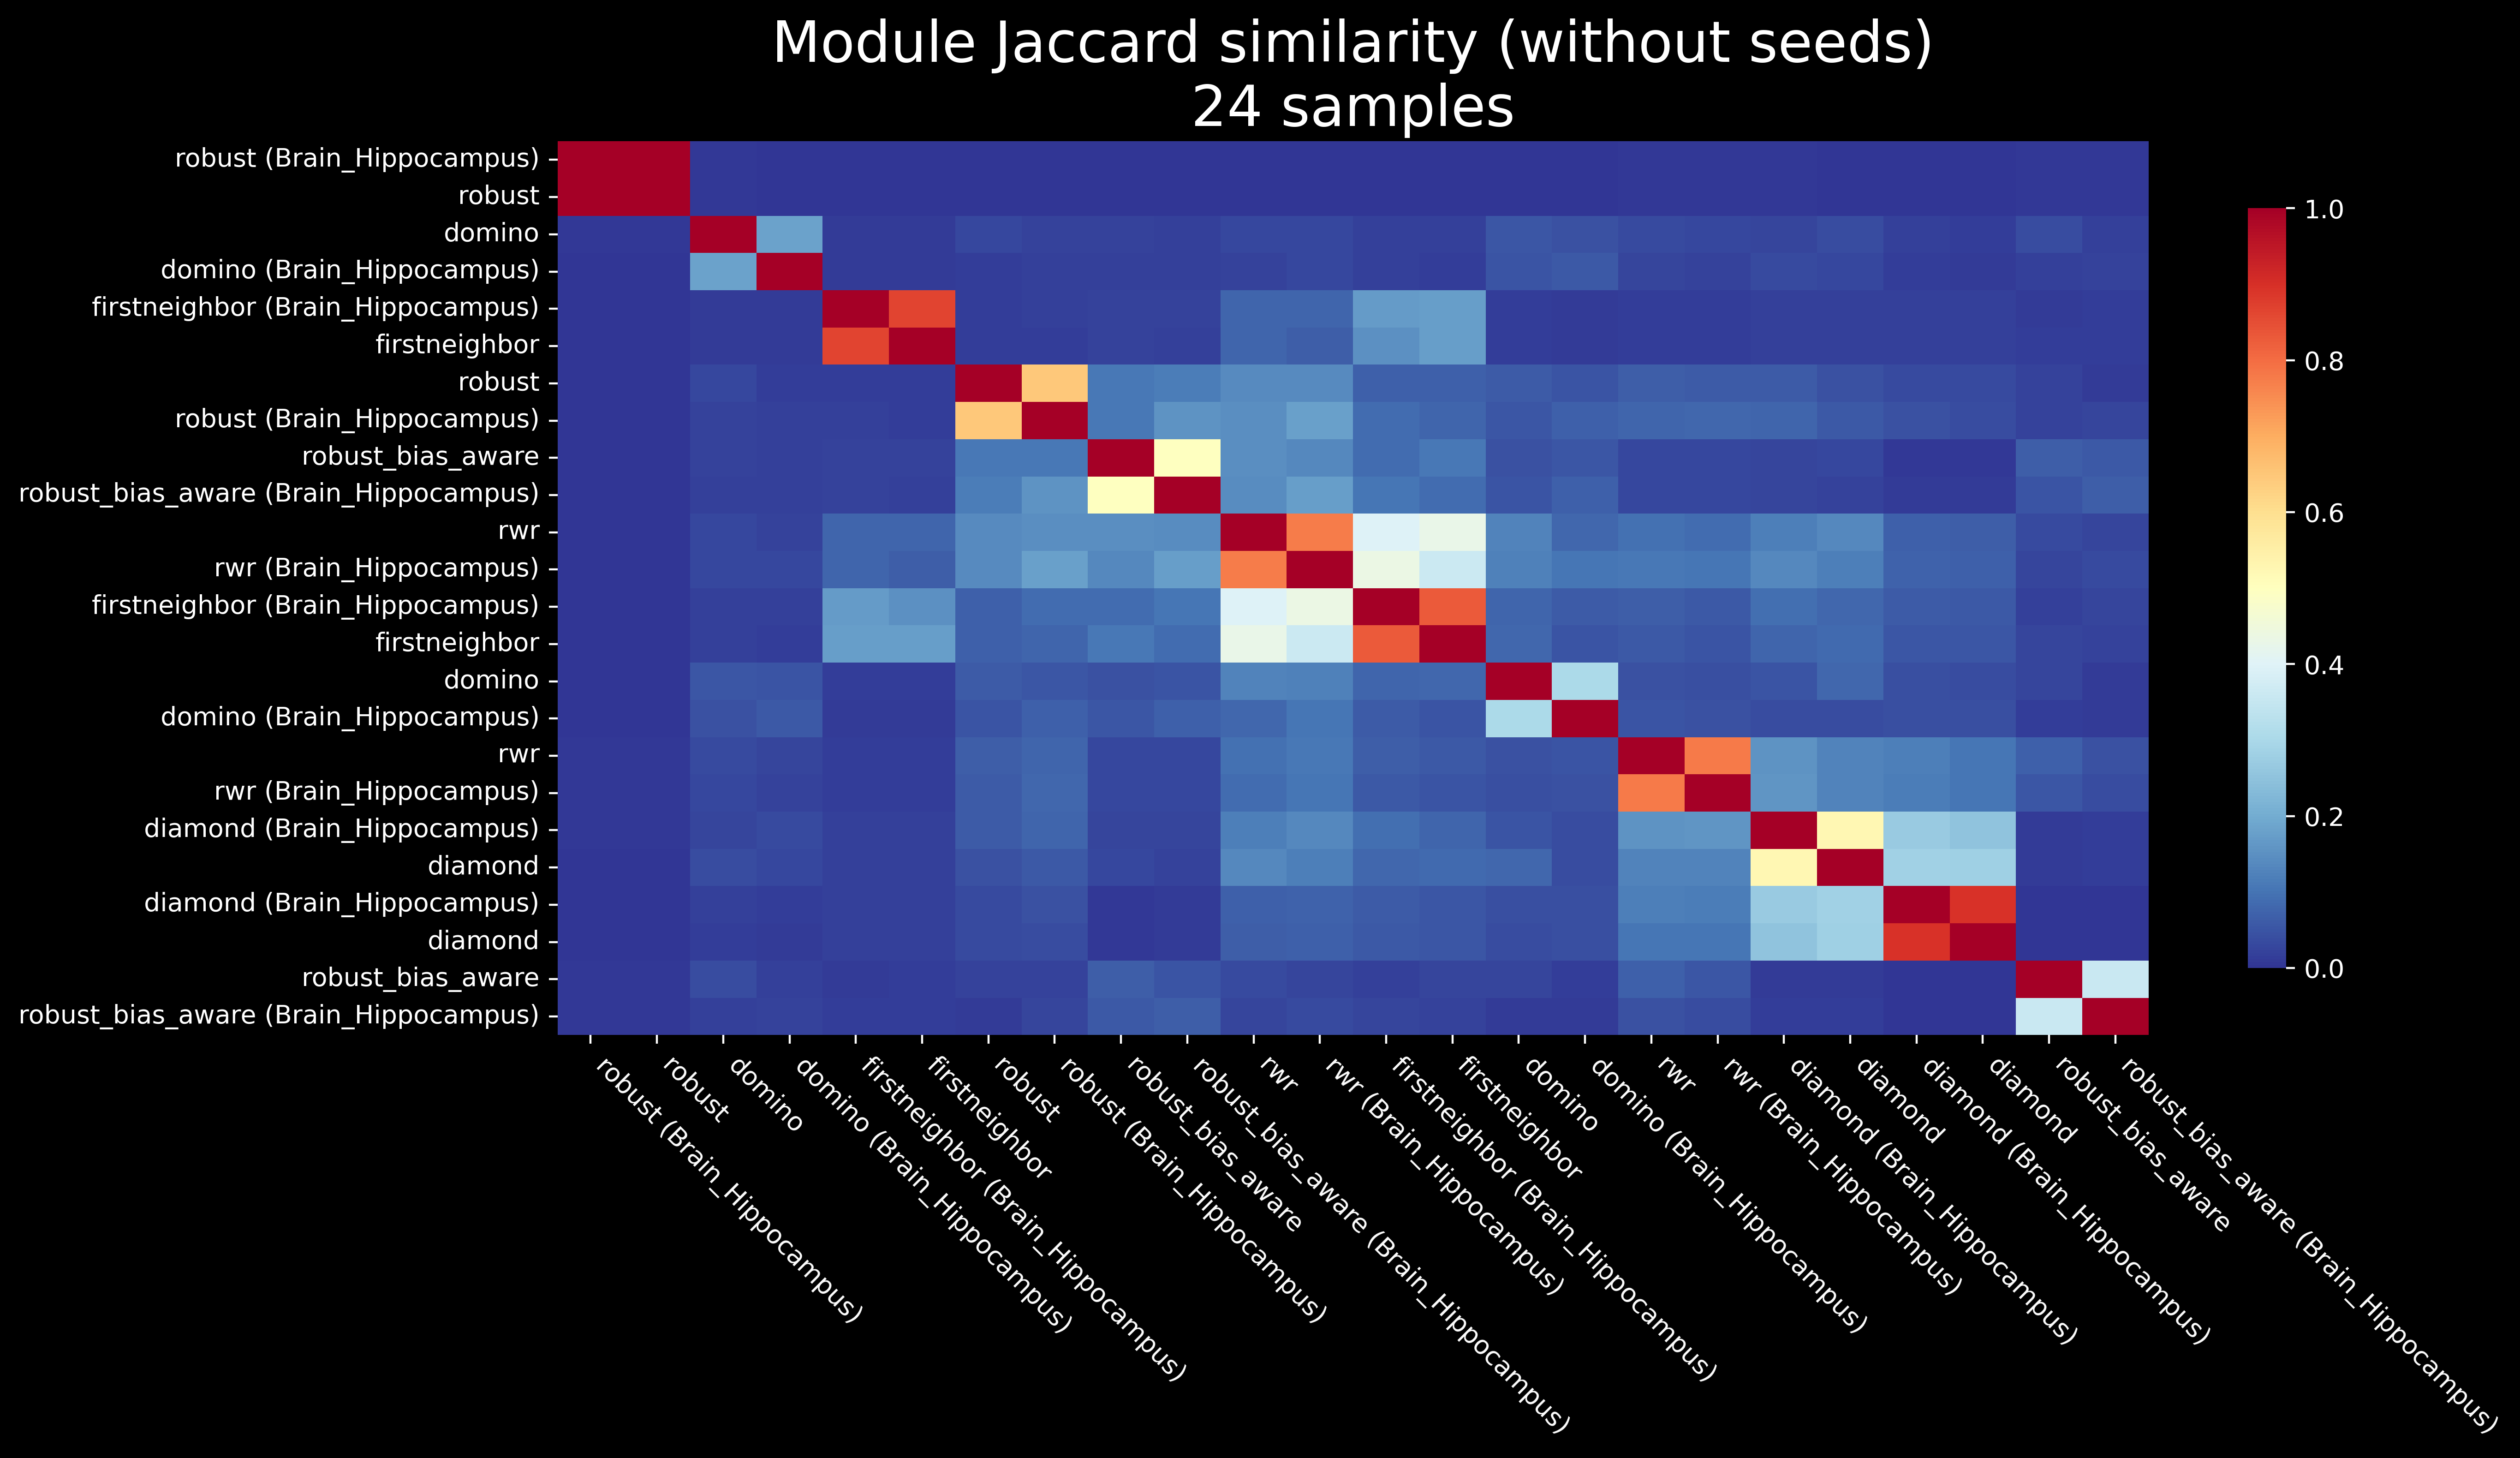

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

similarity_path = "data/jaccard_similarity_no_seeds_matrix_mqc.tsv"
similarity_df = pd.read_csv(similarity_path, sep="\t", index_col=0)

def simplify_sample_name(sample_name: str) -> str:
    parts = sample_name.split(".")
    tool = parts[-1]
    tissue = parts[-2] if len(parts) > 1 and "_" in parts[-2] else None
    return f"{tool} ({tissue})" if tissue else tool

labels = [simplify_sample_name(name) for name in similarity_df.index]
similarity_df.index = labels
similarity_df.columns = labels

# Cluster samples using hierarchical clustering on 1 - similarity.
distance_df = 1 - similarity_df
distance_df = (distance_df + distance_df.T) / 2
for idx in range(len(distance_df)):
    distance_df.iat[idx, idx] = 0.0

linkage_matrix = linkage(squareform(distance_df.to_numpy()), method="average", optimal_ordering=True)
cluster_order = leaves_list(linkage_matrix)
clustered_df = similarity_df.iloc[cluster_order, cluster_order]


sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(14, 8), dpi = 400, facecolor="white")
ax.set_facecolor("white")
sns.heatmap(clustered_df, cmap="RdYlBu_r", vmin=0, vmax=1, ax=ax, cbar_kws={"shrink": 0.85})
ax.set_title(f"Module Jaccard similarity (without seeds)\n{clustered_df.shape[0]} samples", fontsize=22)
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha="left")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


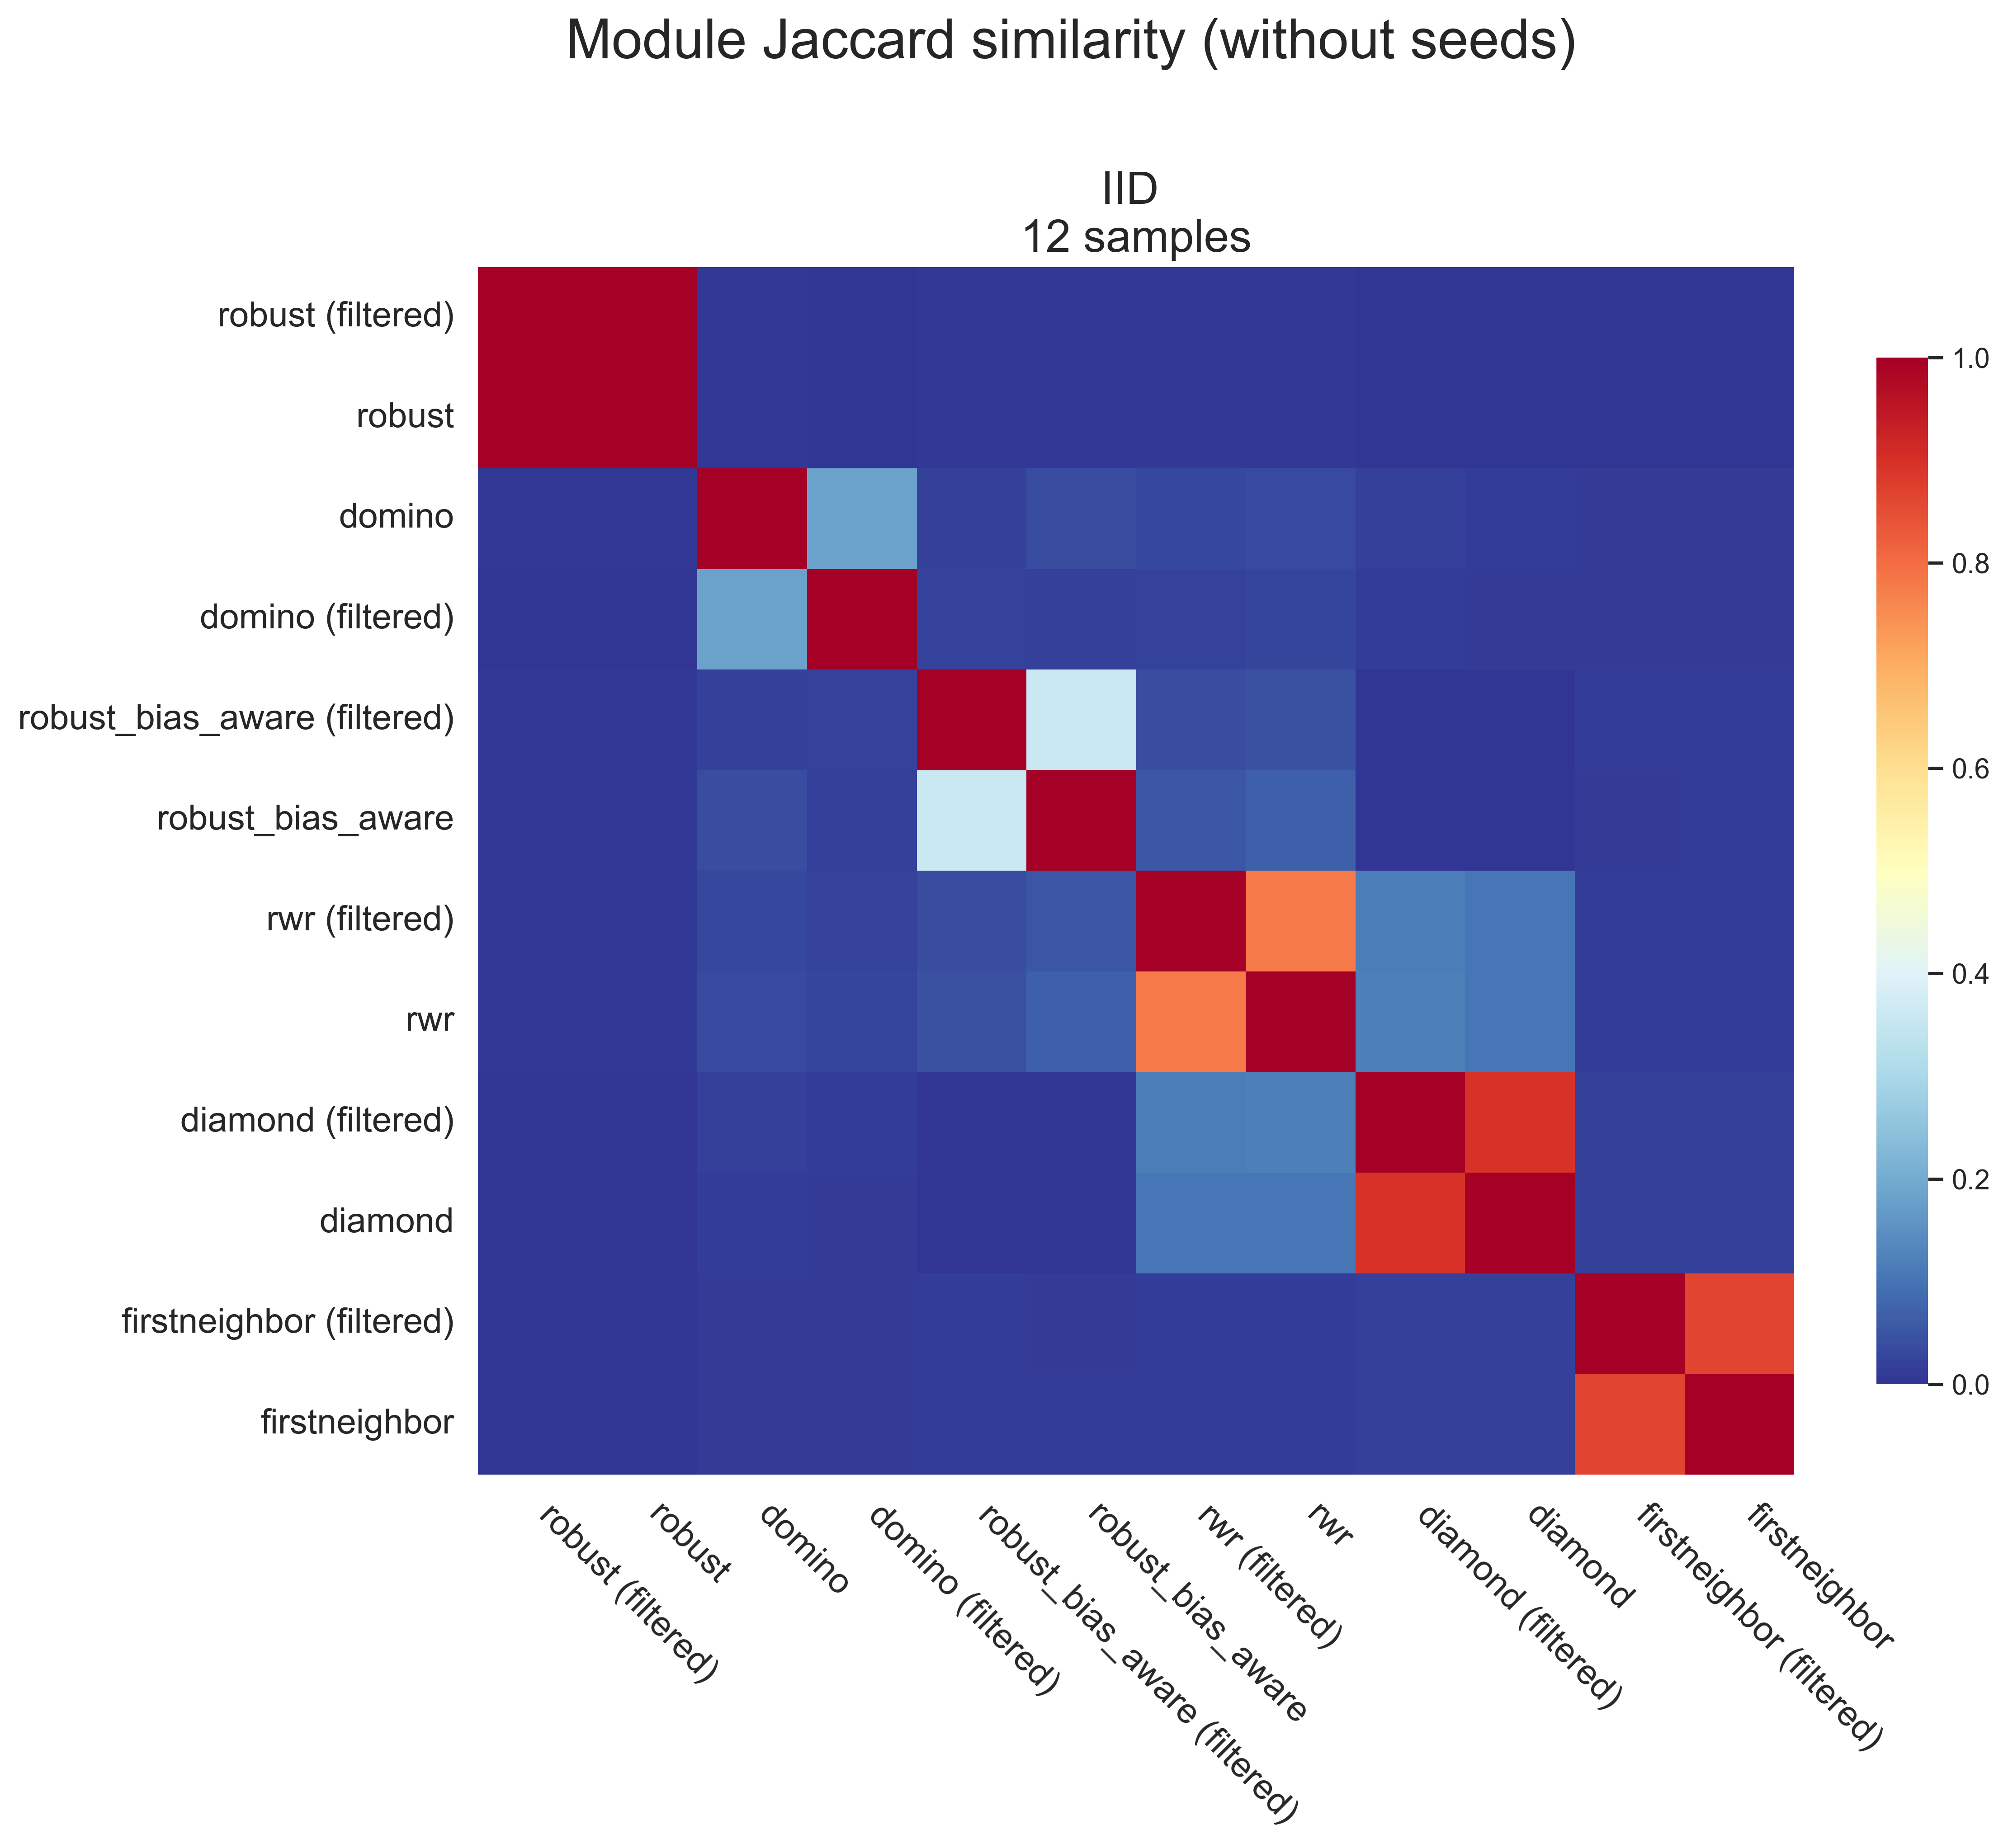

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

similarity_path = "data/jaccard_similarity_no_seeds_matrix_mqc.tsv"
raw_similarity_df = pd.read_csv(similarity_path, sep="\t", index_col=0)

def simplify_sample_name(sample_name: str) -> str:
    parts = sample_name.split(".")
    tool = parts[-1]
    tissue = parts[-2] if len(parts) > 1 and "_" in parts[-2] else None
    return f"{tool} (filtered)" if tissue else tool

def cluster_similarity_matrix(df: pd.DataFrame) -> pd.DataFrame:
    if df.shape[0] <= 1:
        return df
    distance_df = 1 - df
    distance_df = (distance_df + distance_df.T) / 2
    for idx in range(len(distance_df)):
        distance_df.iat[idx, idx] = 0.0
    linkage_matrix = linkage(squareform(distance_df.to_numpy()), method="average", optimal_ordering=True)
    cluster_order = leaves_list(linkage_matrix)
    ordered_labels = df.index[cluster_order].tolist()
    return df.loc[ordered_labels, ordered_labels]

network_label = "iid"
network_token = ".iid."

selected_samples = [sample for sample in raw_similarity_df.index if network_token in sample]
network_df = raw_similarity_df.loc[selected_samples, selected_samples].copy()
simplified_labels = [simplify_sample_name(sample) for sample in network_df.index]
network_df.index = simplified_labels
network_df.columns = simplified_labels
clustered_network_df = cluster_similarity_matrix(network_df)

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 10), dpi=400, facecolor="white")
ax.set_facecolor("white")

sns.heatmap(
    clustered_network_df,
    cmap="RdYlBu_r",
    vmin=0,
    vmax=1,
    ax=ax,
    cbar_kws={"shrink": 0.85},
)

ax.set_title(f"{network_label.upper()} \n{clustered_network_df.shape[0]} samples", fontsize=18)
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha="left", fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)

fig.suptitle("Module Jaccard similarity (without seeds)", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

In [4]:
import requests
import pandas as pd

url = (
    "https://www.proteomicsdb.org/proteomicsdb/logic/api/"
    "tissuelist.xsodata/CA_AVAILABLEBIOLOGICALSOURCES_API"
)

params = {
    "select": ",".join([
        "TISSUE_ID",
        "TISSUE_NAME",
        "TISSUE_GROUP_NAME",
        "TISSUE_CATEGORY",
        "SCOPE_ID",
        "SCOPE_NAME",
        "QUANTIFICATION_METHOD_ID",
        "QUANTIFICATION_METHOD_NAME",
        "MS_LEVEL",
        "TAXCODE"
    ]),
    "$format": "json"
}

headers = {
    "Accept": "application/json"
}

r = requests.get(url, params=params, headers=headers)

print("Status code:", r.status_code)
print("Content-Type:", r.headers.get("Content-Type"))
print("First 500 characters:")
print(r.text[:500])

r.raise_for_status()

data = r.json()

rows = data.get("d", {}).get("results", data)

df = pd.DataFrame(rows)

df.head()

Status code: 200
Content-Type: application/json
First 500 characters:
{"d":{"results":[{"__metadata": {"type":"proteomicsdb.logic.api.tissuelist.CA_AVAILABLEBIOLOGICALSOURCES_APIType","uri":"https://www.proteomicsdb.org/proteomicsdb/logic/api/tissuelist.xsodata/CA_AVAILABLEBIOLOGICALSOURCES_API('112293313832470131')"},"ID":"112293313832470131","TISSUE_ID":"BTO:0000007","TISSUE_NAME":"HEK-293 cell","TISSUE_GROUP_NAME":"kidney","TISSUE_CATEGORY":"cell line","SCOPE_ID":"PDB:101005","SCOPE_NAME":"Full cellular proteome","QUANTIFICATION_METHOD_ID":"PDB:100306","QUANTIF


,__metadata,ID,TISSUE_ID,TISSUE_NAME,TISSUE_GROUP_NAME,TISSUE_CATEGORY,SCOPE_ID,SCOPE_NAME,QUANTIFICATION_METHOD_ID,QUANTIFICATION_METHOD_NAME,MS_LEVEL,TAXCODE,DATASET_IDS
0,{'type': 'proteomicsdb.logic.api.tissuelist.CA...,112293313832470131,BTO:0000007,HEK-293 cell,kidney,cell line,PDB:101005,Full cellular proteome,PDB:100306,Label-free: Intensity,1,9606,NaN
1,{'type': 'proteomicsdb.logic.api.tissuelist.CA...,112293313832470132,BTO:0000007,HEK-293 cell,kidney,cell line,PDB:101009,Post-translational modification,PDB:100306,Label-free: Intensity,1,9606,NaN
2,{'type': 'proteomicsdb.logic.api.tissuelist.CA...,112293313832470133,BTO:0000007,HEK-293 cell,kidney,cell line,PDB:101010,Protein-protein interaction,MS:1001835,SILAC quantitation analysis,1,9606,NaN
3,{'type': 'proteomicsdb.logic.api.tissuelist.CA...,112293313832470134,BTO:0000007,HEK-293 cell,kidney,cell line,PDB:101010,Protein-protein interaction,PDB:100306,Label-free: Intensity,1,9606,NaN
4,{'type': 'proteomicsdb.logic.api.tissuelist.CA...,112293313832470135,BTO:0000007,HEK-293 cell,kidney,cell line,PDB:101015,CETSA (Thermal profile),MS:1002010,TMT quantitation analysis,2,9606,NaN


In [10]:
human_tissues = df[
    (df["TAXCODE"] == 9606) &
    (df["TISSUE_CATEGORY"] == "tissue")
].copy()

tissue_list = (
    human_tissues[["TISSUE_ID", "TISSUE_NAME", "TISSUE_GROUP_NAME"]]
    .drop_duplicates()
    .sort_values("TISSUE_ID")
)

tissue_list.to_csv("proteomicsdb_tissue_list.tsv", sep="\t", index=False)

In [46]:
BASE = "https://www.proteomicsdb.org/proteomicsdb/logic/api_v2/api.xsodata"

metadata_url = f"{BASE}/$metadata"

r = requests.get(metadata_url)

print("Status:", r.status_code)
print("Final URL:", r.url)
print("Content-Type:", r.headers.get("Content-Type"))
print(r.text[:500])

Status: 200
Final URL: https://www.proteomicsdb.org/proteomicsdb/logic/api_v2/api.xsodata/$metadata
Content-Type: application/xml;charset=utf-8
<?xml version="1.0" encoding="utf-8" standalone="yes" ?><edmx:Edmx Version="1.0" xmlns:edmx="http://schemas.microsoft.com/ado/2007/06/edmx"><edmx:DataServices xmlns:m="http://schemas.microsoft.com/ado/2007/08/dataservices/metadata" m:DataServiceVersion="2.0"><Schema Namespace="proteomicsdb.logic.api_v2.api" xmlns:d="http://schemas.microsoft.com/ado/2007/08/dataservices" xmlns:m="http://schemas.microsoft.com/ado/2007/08/dataservices/metadata" xmlns="http://schemas.microsoft.com/ado/2008/09/edm"><


In [18]:
import requests
import xml.etree.ElementTree as ET

root = ET.fromstring(r.text)

ns = {
    "edmx": "http://schemas.microsoft.com/ado/2007/06/edmx",
    "edm": "http://schemas.microsoft.com/ado/2008/09/edm",
}

# Map EntityType names to fields
entity_fields = {}

for entity in root.findall(".//edm:EntityType", ns):
    entity_name = entity.attrib["Name"]
    fields = [p.attrib["Name"] for p in entity.findall("edm:Property", ns)]
    entity_fields[entity_name] = fields

# Map EntitySet names to EntityTypes
for entity_set in root.findall(".//edm:EntitySet", ns):
    set_name = entity_set.attrib["Name"]
    entity_type = entity_set.attrib["EntityType"].split(".")[-1]

    fields = entity_fields.get(entity_type, [])

    if (
        "TISSUE_ID" in fields
        or "NORMALIZED_EXPRESSION" in fields
        or "UNIQUE_IDENTIFIER" in fields
    ):
        print("EntitySet name to use in URL:", set_name)
        print("EntityType:", entity_type)
        print("Fields:", fields)
        print()

EntitySet name to use in URL: Sample
EntityType: SampleType
Fields: ['SAMPLE_ID', 'EXPERIMENT_ID', 'NAME', 'DESCRIPTION', 'TAXCODE', 'TISSUE_ID', 'TISSUE', 'TREATMENT', 'TREATMENT_DETAILS', 'TREATMENT_AGENT', 'DISEASE', 'DISEASE_ID', 'AFFINITY_PURIFICATION', 'COVALENT_PURIFICATION', 'QUANTIFICATION_CHANNEL', 'ONLINE_LIQUID_CHROMATOGRAPHY_SYSTEM', 'CELL_EXTRACT', 'ELECTROPHORESIS', 'CHROMATOGRAPHY_1', 'CHROMATOGRAPHY_2', 'CHROMATOGRAPHY_3', 'CHROMATOGRAPHY_4', 'CHROMATOGRAPHY_5', 'QUANTIFICATION_METHOD', 'PROTEIN_DIGESTION_METHOD', 'MASS_SPECTROMETER', 'PROTEASE_NAME', 'MS_RESOLUTION', 'MSMS_RESOLUTION', 'FRAGMENTATION_METHOD', 'MS_DETECTOR', 'MSMS_DETECTOR', 'ACQUISITION_MODE', 'G_UID']

EntitySet name to use in URL: Protein
EntityType: ProteinType
Fields: ['PROTEIN_ID', 'DATABASE', 'UNIQUE_IDENTIFIER', 'ENTRY_NAME', 'PROTEIN_NAME', 'TAXCODE', 'GENE_NAME', 'PROTEIN_EXISTENCE', 'SEQUENCE_VERSION', 'PARENT_PROTEIN_ID', 'DECOY', 'CONTAMINANT', 'MASS', 'G_UID']

EntitySet name to use in UR

In [57]:
bto_ids = ["BTO:0000047", "BTO:0000233", "BTO:0000988"]

def get_tissue_expression_v2(bto_id):
    url = f"{BASE}/Tissue('{bto_id}')/ProteinExpression"

    r = requests.get(url, params={"$format": "json"})
    r.raise_for_status()

    data = r.json()
    rows = data.get("d", {}).get("results", data)

    df = pd.DataFrame(rows)
    df = df.drop(columns=["__metadata"], errors="ignore")

    df = df[["PROTEIN_ID", "EXPRESSION"]].copy()
    df["EXPRESSION"] = pd.to_numeric(
        df["EXPRESSION"],
        errors="coerce"
    )
    # make sure one protein only has one value per tissue
    df = (
        df.groupby("PROTEIN_ID", as_index=False)["EXPRESSION"]
        .mean()
    )

    df = df.rename(columns={"EXPRESSION": bto_id})

    return df

all_tissue_dfs = []

for bto_id in bto_ids: 
    print(f"Querying {bto_id}")
    try:
        df_tissue = get_tissue_expression_v2(bto_id=bto_id)
        all_tissue_dfs.append(df_tissue)
    except Exception as e: 
        print(f"skipping {bto_id}: {e}")

Querying BTO:0000047
Querying BTO:0000233
Querying BTO:0000988


In [59]:
from functools import reduce 
expression_matrix = reduce(
    lambda left, right : pd.merge(left, right, on="PROTEIN_ID", how="outer"),
    all_tissue_dfs
)
expression_matrix.fillna(value=0,inplace=True)
expression_matrix.head()


,PROTEIN_ID,BTO:0000047,BTO:0000233,BTO:0000988
0,3,7.016302,0.0,0.000000
1,9,0.000000,0.0,7.684894
2,10,0.000000,0.0,7.667513
3,11,0.000000,0.0,7.694135
4,12,0.000000,0.0,7.724484


In [60]:
example_id = int(expression_matrix["PROTEIN_ID"].dropna().iloc[0])

url = f"{BASE}/Protein({example_id})"

r = requests.get(url, params={"$format": "json"})
r.raise_for_status()

example_protein = r.json().get("d", r.json())

example_protein

{'__metadata': {'type': 'proteomicsdb.logic.api_v2.api.ProteinType',
  'uri': 'https://www.proteomicsdb.org/proteomicsdb/logic/api_v2/api.xsodata/Protein(3)'},
 'PROTEIN_ID': 3,
 'DATABASE': 'tr',
 'UNIQUE_IDENTIFIER': 'A0AUL9',
 'ENTRY_NAME': 'A0AUL9_HUMAN',
 'PROTEIN_NAME': 'ATG2A protein (Fragment)',
 'TAXCODE': 9606,
 'GENE_NAME': 'ATG2A',
 'PROTEIN_EXISTENCE': 2,
 'SEQUENCE_VERSION': 1,
 'PARENT_PROTEIN_ID': 3,
 'DECOY': 0,
 'CONTAMINANT': 0,
 'MASS': '56375.93749999976',
 'G_UID': 'PRDB_UID:PRDB:PROTEIN:3',
 'Peptide': {'__deferred': {'uri': 'https://www.proteomicsdb.org/proteomicsdb/logic/api_v2/api.xsodata/Protein(3)/Peptide'}},
 'ProteinAttribute': {'__deferred': {'uri': 'https://www.proteomicsdb.org/proteomicsdb/logic/api_v2/api.xsodata/Protein(3)/ProteinAttribute'}},
 'Species': {'__deferred': {'uri': 'https://www.proteomicsdb.org/proteomicsdb/logic/api_v2/api.xsodata/Protein(3)/Species'}},
 'Curve': {'__deferred': {'uri': 'https://www.proteomicsdb.org/proteomicsdb/logic/api

In [63]:
def get_protein_mapping(protein_id):
    url = f"{BASE}/Protein({int(protein_id)})"

    r = requests.get(url, params={"$format": "json"})
    r.raise_for_status()

    data = r.json().get("d", r.json())

    return {
        "PROTEIN_ID": int(protein_id),

        # Try common possible UniProt fields
        "UNIPROT_ID": (
            data.get("UNIQUE_IDENTIFIER")
            or data.get("UNIPROT_ID")
            or data.get("UNIPROT_ACCESSION")
            or data.get("ACCESSION")
        ),

        "DATABASE": data.get("DATABASE"),
        "ENTRY_NAME": data.get("ENTRY_NAME"),
        "GENE_NAME": data.get("GENE_NAME"),
        "PROTEIN_DESCRIPTION": data.get("PROTEIN_DESCRIPTION"),
    }

In [64]:

protein_ids = (
    expression_matrix["PROTEIN_ID"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

mapping_rows = []

for protein_id in protein_ids:
    try:
        mapping_rows.append(get_protein_mapping(protein_id))
    except Exception as e:
        print(f"Could not map PROTEIN_ID {protein_id}: {e}")

protein_mapping = pd.DataFrame(mapping_rows)

protein_mapping.head()

,PROTEIN_ID,UNIPROT_ID,DATABASE,ENTRY_NAME,GENE_NAME,PROTEIN_DESCRIPTION
0,3,A0AUL9,tr,A0AUL9_HUMAN,ATG2A,None
1,9,A0AV02,sp,S12A8_HUMAN,SLC12A8,None
2,10,A0AV02-2,sp,S12A8_HUMAN,SLC12A8,None
3,11,A0AV02-3,sp,S12A8_HUMAN,SLC12A8,None
4,12,A0AV02-4,sp,S12A8_HUMAN,SLC12A8,None


In [66]:
expression_matrix_uniprot = protein_mapping.merge(
    expression_matrix,
    on="PROTEIN_ID",
    how="right"
)

expression_matrix_uniprot.head()
print(expression_matrix_uniprot.shape)

(81171, 9)


In [67]:
# Keep only rows where a UniProt ID was found
expression_matrix_uniprot = expression_matrix_uniprot.dropna(
    subset=["UNIPROT_ID"]
).copy()
print(expression_matrix_uniprot.shape)

# Optional: if multiple ProteomicsDB IDs map to the same UniProt ID,
# average their expression values
metadata_cols = [
    "UNIPROT_ID",
    "DATABASE",
    "ENTRY_NAME",
    "GENE_NAME",
    "PROTEIN_DESCRIPTION",
    "PROTEIN_ID"
]

expression_cols = [
    col for col in expression_matrix_uniprot.columns
    if col not in metadata_cols
]

expression_matrix_uniprot_final = (
    expression_matrix_uniprot
    .groupby("UNIPROT_ID", as_index=False)[expression_cols]
    .mean()
)

expression_matrix_uniprot_final.head()

(81171, 9)


,UNIPROT_ID,BTO:0000047,BTO:0000233,BTO:0000988
0,A0A067XG46,6.320644,0.0,0.000000
1,A0A067XG49,6.426055,0.0,0.000000
2,A0A067XG53,7.419995,0.0,6.373859
3,A0A075B5J6,6.841463,0.0,0.000000
4,A0A075B5K0,6.934498,0.0,0.000000
